决策边界方程: -11.74 + 1.53*x1 + 3.11*x2 = 0


C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packa

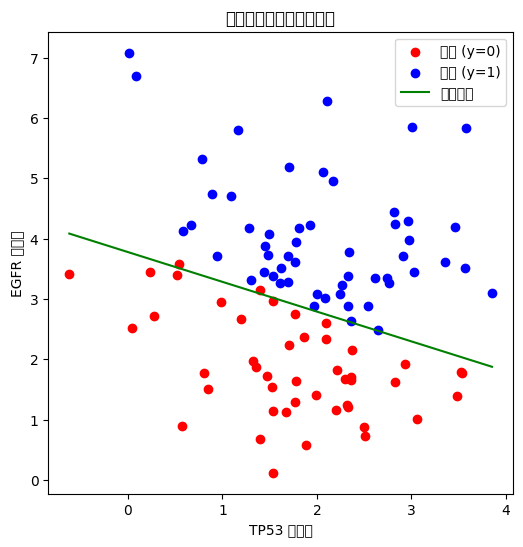

代价函数值 (Log Loss): 0.1409


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# 1. 构建模拟数据集
np.random.seed(42)
n_samples = 100

# 随机生成两个基因表达量
x1 = np.random.normal(loc=2.0, scale=1.0, size=n_samples)   # TP53
x2 = np.random.normal(loc=3.0, scale=1.5, size=n_samples)   # EGFR

# 标签：人为设定一个分界规则
y = (0.8*x1 + 1.2*x2 - 5 > 0).astype(int)

X = np.column_stack((x1, x2))

# 2. 训练逻辑回归模型
model = LogisticRegression()
model.fit(X, y)

# 3. 决策边界方程
theta0 = model.intercept_[0]
theta1, theta2 = model.coef_[0]
print("决策边界方程: {:.2f} + {:.2f}*x1 + {:.2f}*x2 = 0".format(theta0, theta1, theta2))

# 4. 可视化数据点和决策边界
plt.figure(figsize=(6,6))
plt.scatter(x1[y==0], x2[y==0], color='red', label='耐药 (y=0)')
plt.scatter(x1[y==1], x2[y==1], color='blue', label='敏感 (y=1)')

# 决策边界直线
x1_range = np.linspace(min(x1), max(x1), 100)
x2_boundary = -(theta0 + theta1*x1_range)/theta2
plt.plot(x1_range, x2_boundary, color='green', label='决策边界')

plt.xlabel("TP53 表达量")
plt.ylabel("EGFR 表达量")
plt.legend()
plt.title("逻辑回归决策边界示意图")
plt.show()

# 5. 计算代价函数值
y_pred_prob = model.predict_proba(X)[:,1]
cost = log_loss(y, y_pred_prob)
print("代价函数值 (Log Loss): {:.4f}".format(cost))


(100, 2)
Epoch 500: Loss=0.5675
Epoch 1000: Loss=0.5602
Epoch 1500: Loss=0.5591
Epoch 2000: Loss=0.5589
Epoch 2500: Loss=0.5588
Epoch 3000: Loss=0.5588


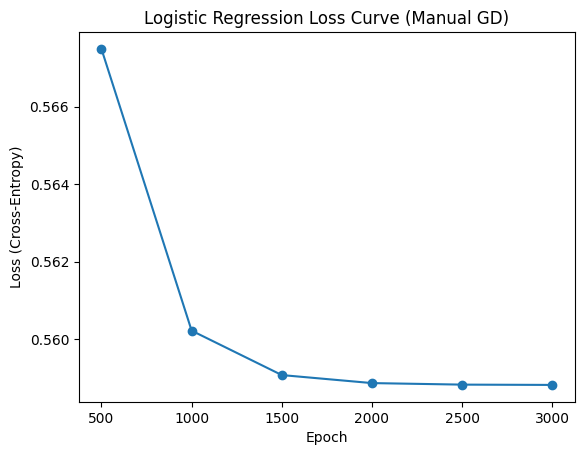

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# 1. 构建模拟数据集
np.random.seed(42)
n_samples = 100

# 随机生成两个基因表达量
x1 = np.random.normal(loc=2.0, scale=1.0, size=n_samples)   # TP53
x2 = np.random.normal(loc=3.0, scale=1.5, size=n_samples)   # EGFR

# 标签：人为设定一个分界规则
y = (0.8*x1 + 1.2*x2 - 5 > 0).astype(int)

X = np.column_stack((x1, x2))
print(X.shape)
y = y.reshape(-1,1)

# 2. 手动训练逻辑回归模型，不加截距项
# 假设 X 是特征矩阵 (n_samples, n_features)，y 是标签 (n_samples, 1)

w = np.zeros((X.shape[1], 1))   # 初始化权重
lr = 0.01
epochs = 3000
losses = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    # 1. 前向传播
    z = X.dot(w)
    y_hat = sigmoid(z)

    # 2. 计算误差
    error = y_hat - y

    # 3. 计算梯度
    grad = (1/n_samples) * X.T.dot(error)

    # 4. 更新权重
    w -= lr * grad

    # 5. 计算交叉熵损失
    if (epoch+1) % 500 == 0:
        loss = -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))
        losses.append(loss)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}")

# 可视化 Loss 曲线
import matplotlib.pyplot as plt
plt.plot(range(500, epochs+1, 500), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Logistic Regression Loss Curve (Manual GD)")
plt.show()


(100, 2)
Epoch 500: Loss=0.5251
Epoch 1000: Loss=0.4847
Epoch 1500: Loss=0.4556
Epoch 2000: Loss=0.4313
Epoch 2500: Loss=0.4101
Epoch 3000: Loss=0.3916
决策边界方程: -2.16 + -0.15*x1 + 1.00*x2 = 0


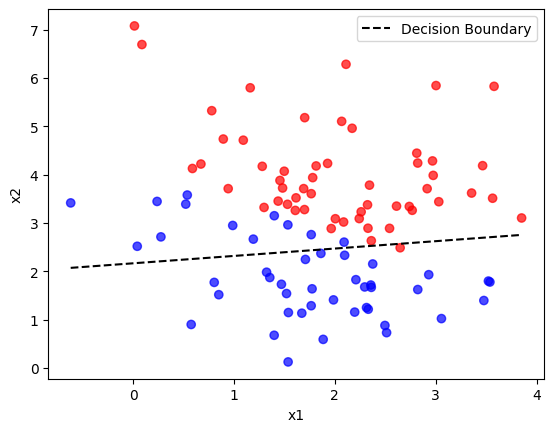

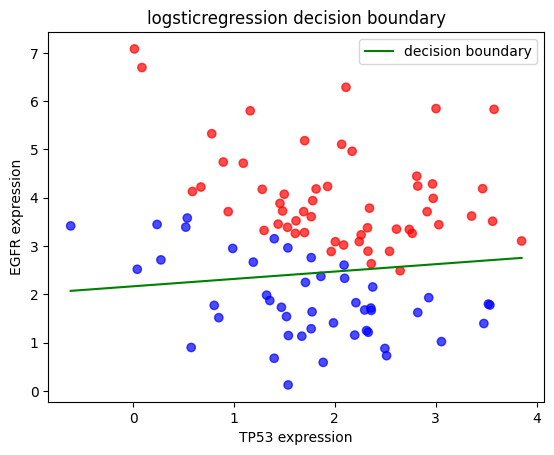

代价函数值 (Log Loss, 手动): 0.3916


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 构建模拟数据集
np.random.seed(42)
n_samples = 100

# 随机生成两个基因表达量
x1 = np.random.normal(loc=2.0, scale=1.0, size=n_samples)   # TP53
x2 = np.random.normal(loc=3.0, scale=1.5, size=n_samples)   # EGFR

# 标签：人为设定一个分界规则
y = (0.8*x1 + 1.2*x2 - 5 > 0).astype(int)

X = np.column_stack((x1, x2))
print(X.shape)
y = y.reshape(-1,1)

# 2. 手动训练逻辑回归模型，不加截距项
# 假设你已经有 X (n_samples, 2) 和 y (n_samples, 1)

n_samples = X.shape[0]
X_aug = np.hstack([np.ones((n_samples,1)), X])  # 加截距列
y = y.reshape(-1,1)

# 初始化参数
w = np.zeros((X_aug.shape[1],1))
lr = 0.01
epochs = 3000
losses = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    # 前向传播
    z = X_aug.dot(w)
    y_hat = sigmoid(z)

    # 计算梯度
    grad = (1/n_samples) * X_aug.T.dot(y_hat - y)

    # 更新权重
    w -= lr * grad

    # 每500次打印一次损失
    if (epoch+1) % 500 == 0:
        loss = -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))
        losses.append(loss)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}")

# ===== 提取决策边界方程 =====
theta0, theta1, theta2 = w.flatten()
print(f"决策边界方程: {theta0:.2f} + {theta1:.2f}*x1 + {theta2:.2f}*x2 = 0")

# ===== 可视化决策边界 =====
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='bwr', alpha=0.7)
x1_line = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_line = -(theta0 + theta1*x1_line) / (theta2 + 1e-12)  # 避免除零
plt.plot(x1_line, x2_line, 'k--', label='Decision Boundary')
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.show()


x1_range = np.linspace(min(x1), max(x1), 100)
x2_boundary = -(theta0 + theta1*x1_range) / (theta2 + 1e-8)  # 避免除零

plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='bwr', alpha=0.7)
plt.plot(x1_range, x2_boundary, color='green', label='decision boundary')
plt.xlabel("TP53 expression")
plt.ylabel("EGFR expression")
plt.legend()
plt.title("logsticregression decision boundary")
plt.show()


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 前向传播得到预测概率
z = X_aug.dot(w)          # X_aug 包含截距列
y_pred_prob = sigmoid(z)  # (n_samples,1)

# 手动计算 log loss
cost = -np.mean(y*np.log(y_pred_prob+1e-8) + (1-y)*np.log(1-y_pred_prob+1e-8))
print(f"代价函数值 (Log Loss, 手动): {cost:.4f}")



(200, 3)
Epoch 500: Loss=0.2199
Epoch 1000: Loss=0.1313
Epoch 1500: Loss=0.0984
Epoch 2000: Loss=0.0816
Epoch 2500: Loss=0.0715
Epoch 3000: Loss=0.0646
Epoch 3500: Loss=0.0597
Epoch 4000: Loss=0.0559
Epoch 4500: Loss=0.0528
Epoch 5000: Loss=0.0503
Epoch 5500: Loss=0.0482
Epoch 6000: Loss=0.0464
Epoch 6500: Loss=0.0448
Epoch 7000: Loss=0.0434
Epoch 7500: Loss=0.0421
Epoch 8000: Loss=0.0409
Epoch 8500: Loss=0.0399
Epoch 9000: Loss=0.0390
Epoch 9500: Loss=0.0381
Epoch 10000: Loss=0.0373


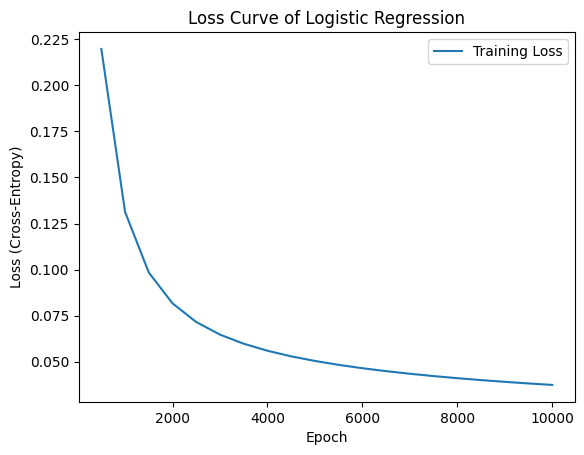

决策边界方程: 4.36 + 0.96*x1 + 0.34*x2 = 0


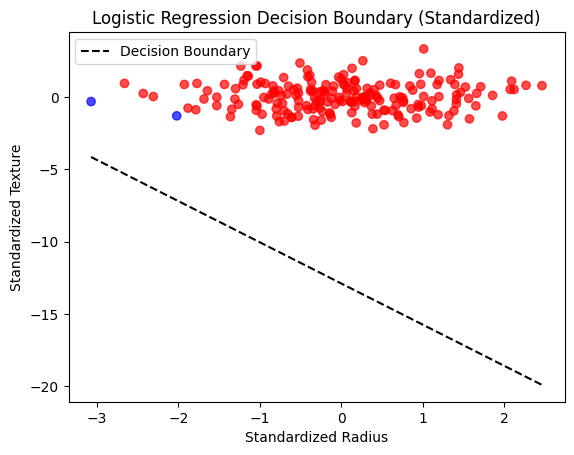

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 构建模拟数据集
np.random.seed(123)
n_samples = 200
radius = np.random.normal(loc=5.0, scale=1.0, size=n_samples)
texture = np.random.normal(loc=10.0, scale=2.0, size=n_samples)

y = (1.5*radius + 0.5*texture - 8 > 0).astype(int)
X = np.column_stack((radius, texture))

#特征缩放
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # 对 radius 和 texture 做标准化
X_aug = np.hstack([np.ones((X_scaled.shape[0],1)), X_scaled])

y = y.reshape(-1,1)
print(X_aug.shape)

w = np.zeros((X_aug.shape[1],1))
lr = 0.01
epochs = 10000

def sigmoid(z):
    return 1 / (1 + np.exp(-z)) 

losses = []

# 2.开始学习
for epoch in range(epochs):
    z = X_aug.dot(w) 
    y_hat = sigmoid(z)
    error = y_hat - y
    grad = (1/n_samples) * X_aug.T.dot(error)
    w -= lr*grad

    
    # 用交叉熵计算loss 
    if (epoch+1) % 500 == 0:
        loss = -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))
        losses.append(loss)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}")

# 绘制 Loss 曲线
plt.plot(range(500,epochs+1,500), losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Loss Curve of Logistic Regression")
plt.legend()
plt.show()

# 提取决策边界方程
theta0, theta1, theta2 = w.flatten()
print(f"决策边界方程: {theta0:.2f} + {theta1:.2f}*x1 + {theta2:.2f}*x2 = 0")

# 决策边界横轴范围（标准化后的 radius）
x1_range = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)

# 决策边界公式（标准化空间）
x2_boundary = -(theta0 + theta1*x1_range) / (theta2 + 1e-8)

# 绘图：用标准化后的特征
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y.flatten(), cmap='bwr', alpha=0.7)
plt.plot(x1_range, x2_boundary, 'k--', label='Decision Boundary')
plt.xlabel("Standardized Radius")
plt.ylabel("Standardized Texture")
plt.title("Logistic Regression Decision Boundary (Standardized)")
plt.legend()
plt.show()




截距 theta0: [-0.33467326]
系数 theta1, theta2: [[4.30027554 2.49390818]]


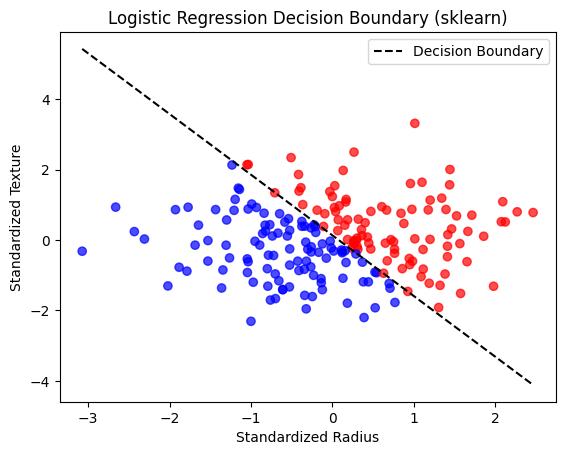

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. 构建模拟数据集
np.random.seed(123)
n_samples = 200
radius = np.random.normal(loc=5.0, scale=1.0, size=n_samples)
texture = np.random.normal(loc=10.0, scale=2.0, size=n_samples)

y = (1.5*radius + 0.5*texture - 12.5 > 0).astype(int)  # 调整阈值让类别更均衡
X = np.column_stack((radius, texture))

# 2. 特征缩放
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 用 sklearn 训练逻辑回归
clf = LogisticRegression()
clf.fit(X_scaled, y)

print("截距 theta0:", clf.intercept_)
print("系数 theta1, theta2:", clf.coef_)

# 4. 决策边界绘制
theta0 = clf.intercept_[0]
theta1, theta2 = clf.coef_[0]

x1_range = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 200)
x2_boundary = -(theta0 + theta1*x1_range) / (theta2 + 1e-8)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y, cmap='bwr', alpha=0.7)
plt.plot(x1_range, x2_boundary, 'k--', label='Decision Boundary')
plt.xlabel("Standardized Radius")
plt.ylabel("Standardized Texture")
plt.title("Logistic Regression Decision Boundary (sklearn)")
plt.legend()
plt.show()
